<img src="../Pierian-Data-Logo.PNG">
<br>
<strong><center>Copyright 2019. Created by Jose Marcial Portilla.</center></strong>

# Datasets with PyTorch
In this section we'll show how to:
* load data from outside files
* build random batches using PyTorch's <a href='https://pytorch.org/docs/stable/data.html'><strong><tt>data</tt></strong></a> utilities<br>

At the end we'll briefly mention <a href='https://pytorch.org/docs/stable/torchvision/index.html'><tt><strong>torchvision</strong></tt></a>.

## Perform standard imports

In [1]:
import torch
import numpy as np
import seaborn as sns
sns.set()
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

# Loading data from files
We've seen how to load NumPy arrays into PyTorch, and anyone familiar with <tt>pandas.read_csv()</tt> can use it to prepare data before forming tensors. Here we'll load the <a href='https://en.wikipedia.org/wiki/Iris_flower_data_set'>iris flower dataset</a> saved as a .csv file.

In [2]:
from google.colab import files
uploaded_files = files.upload()

Saving iris.csv to iris.csv


In [71]:
df = pd.read_csv('iris.csv')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [72]:
df.shape

(150, 5)

In [73]:
df.target.value_counts()

,count
target,
0.0,50
1.0,50
2.0,50


In [74]:
df.target.value_counts(normalize=True)

,proportion
target,
0.0,0.333333
1.0,0.333333
2.0,0.333333


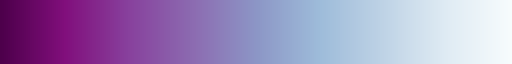

In [11]:
plt.cm.BuPu_r

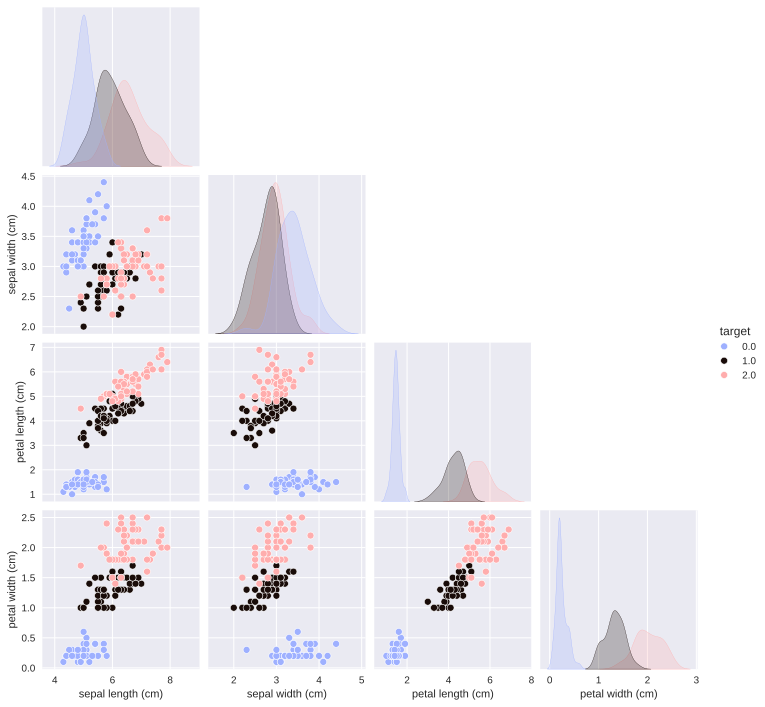

In [75]:
sns.pairplot(df ,
             corner = True,
             diag_kind='kde',
             hue = "target",
             palette="berlin")
plt.show()

## Plot the data

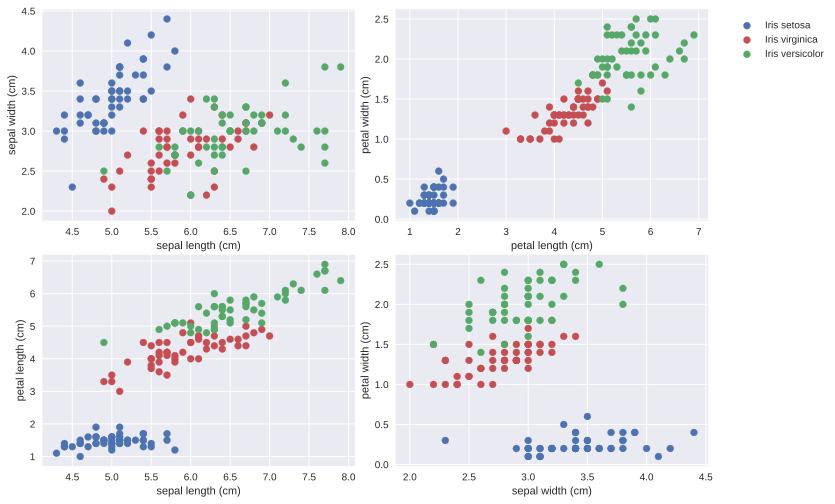

In [76]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,7))
fig.tight_layout()

plots = [(0,1),(2,3),(0,2),(1,3)]
colors = ['b', 'r', 'g']
labels = ['Iris setosa','Iris virginica','Iris versicolor']

for i, ax in enumerate(axes.flatten()):
    for j in range(len(labels)):
        x = df.columns[plots[i][0]]
        y = df.columns[plots[i][1]]
        ax.scatter(df[df['target'] == j][x],
                   df[df['target'] == j][y],
                   color = colors[j])
        ax.set(xlabel = x , ylabel = y)

fig.legend(labels = labels,
           loc = 3,
           bbox_to_anchor = (1.0,0.85))
plt.show()

In [77]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

The iris dataset consists of 50 samples each from three species of Iris (<em>Iris setosa</em>, <em>Iris virginica</em> and <em>Iris versicolor</em>), for 150 total samples. We have four features (sepal length & width, petal length & width) and three unique labels:

0. <em>Iris setosa</em>
1. <em>Iris virginica</em>
2. <em>Iris versicolor</em>

### The classic method for building train/test split tensors
Before introducing PyTorch's Dataset and DataLoader classes, we'll take a quick look at the alternative.

In [78]:
from sklearn.model_selection import train_test_split

train_X , test_X , train_y , test_y = (
    train_test_split(
        df.drop("target" , axis = 1).values,
        df["target"].values,
        test_size=0.2,
        random_state=33
    )
    )

X_train = torch.FloatTensor(train_X)
X_test = torch.FloatTensor(test_X)
y_train = torch.LongTensor(train_y).reshape(-1,1)
y_test = torch.LongTensor(test_y).reshape(-1,1)

In [92]:
data = {"X_train": X_train ,
        "X_test" : X_test ,
        "y_train" : y_train ,
        "y_test" : y_test}

for k , v in data.items():
  print(f"length of {k} : {len(v)}" , sep = "\n")

length of X_train : 120
length of X_test : 30
length of y_train : 120
length of y_test : 30


In [93]:
y_train.unique(return_counts=False)

tensor([0, 1, 2])

In [96]:
y_train.unique(return_counts=True)

(tensor([0, 1, 2]), tensor([42, 42, 36]))

In [101]:
labels , counts = y_train.unique(return_counts=True)
print("labels:", labels)
print()
print("counts:", counts)
print()
print("Total counts:" , counts.sum())

labels: tensor([0, 1, 2])

counts: tensor([42, 42, 36])

Total counts: tensor(120)


<div class="alert alert-success"><strong>NOTE: </strong>The importance of a balanced training set is discussed in <em>A systematic study of the class imbalance problem in convolutional neural networks</em> by Mateusz Buda, Atsuto Maki, Maciej A. Mazurowski (10/15/17, latest rev 10/13/18) <a href='https://arxiv.org/abs/1710.05381'>https://arxiv.org/abs/1710.05381</a><br>For example, the authors show that oversampling a less common class so that it matches the more common classes is always the preferred choice.</div>

In [ ]:
X_train.size()

torch.Size([120, 4])

In [ ]:
y_train.size()

torch.Size([120, 1])

<div class="alert alert-info"><strong>NOTE: </strong>It's up to us to remember which columns correspond to which features.</div>

## Using PyTorch's Dataset and DataLoader classes
A far better alternative is to leverage PyTorch's <a href='https://pytorch.org/docs/stable/data.html'><strong><tt>Dataset</tt></strong></a> and <a href='https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader'><strong><tt>DataLoader</strong></tt></a> classes.

Usually, to set up a Dataset specific to our investigation we would define our own custom class that inherits from <tt>torch.utils.data.Dataset</tt> (we'll do this in the CNN section). For now, we can use the built-in <a href='https://pytorch.org/docs/stable/data.html#torch.utils.data.TensorDataset'><strong><tt>TensorDataset</tt></strong></a> class.

In [104]:
from torch.utils.data import TensorDataset , DataLoader

In [107]:
TensorDataset.__init__

<function torch.utils.data.dataset.TensorDataset.__init__(self, *tensors: torch.Tensor) -> None>

In [112]:
data = df.drop(columns = ["target"]).values
labels = df["target"].values

In [113]:
iris = TensorDataset(torch.FloatTensor(data),
                     torch.LongTensor(labels))
iris

In [114]:
len(iris)

150

In [115]:
type(iris)

torch.utils.data.dataset.TensorDataset

Once we have a dataset we can wrap it with a DataLoader. This gives us a powerful sampler that provides single- or multi-process iterators over the dataset.

In [160]:
iris_loader = DataLoader(iris, batch_size=10, shuffle=True)

In [161]:
for i in list(iris_loader):
  print(i)

[tensor([[7.9000, 3.8000, 6.4000, 2.0000],
        [6.3000, 2.3000, 4.4000, 1.3000],
        [6.0000, 2.2000, 4.0000, 1.0000],
        [5.7000, 2.9000, 4.2000, 1.3000],
        [4.4000, 3.2000, 1.3000, 0.2000],
        [5.1000, 2.5000, 3.0000, 1.1000],
        [5.5000, 4.2000, 1.4000, 0.2000],
        [6.5000, 3.2000, 5.1000, 2.0000],
        [6.5000, 2.8000, 4.6000, 1.5000],
        [5.4000, 3.4000, 1.5000, 0.4000]]), tensor([2, 1, 1, 1, 0, 1, 0, 2, 1, 0])]
[tensor([[5.4000, 3.0000, 4.5000, 1.5000],
        [6.3000, 2.9000, 5.6000, 1.8000],
        [5.5000, 2.6000, 4.4000, 1.2000],
        [7.2000, 3.6000, 6.1000, 2.5000],
        [5.8000, 2.7000, 5.1000, 1.9000],
        [5.8000, 2.7000, 5.1000, 1.9000],
        [4.4000, 3.0000, 1.3000, 0.2000],
        [5.0000, 3.4000, 1.5000, 0.2000],
        [5.5000, 2.4000, 3.8000, 1.1000],
        [6.9000, 3.2000, 5.7000, 2.3000]]), tensor([1, 2, 1, 2, 2, 2, 0, 0, 1, 2])]
[tensor([[5.5000, 3.5000, 1.3000, 0.2000],
        [5.6000, 2.9000, 3.6000

In [162]:
list(iris_loader)[0]

[tensor([[6.4000, 3.1000, 5.5000, 1.8000],
         [6.3000, 2.3000, 4.4000, 1.3000],
         [5.0000, 3.0000, 1.6000, 0.2000],
         [4.4000, 2.9000, 1.4000, 0.2000],
         [4.8000, 3.4000, 1.9000, 0.2000],
         [5.6000, 2.9000, 3.6000, 1.3000],
         [7.4000, 2.8000, 6.1000, 1.9000],
         [5.6000, 2.7000, 4.2000, 1.3000],
         [6.9000, 3.1000, 5.4000, 2.1000],
         [5.5000, 2.3000, 4.0000, 1.3000]]),
 tensor([2, 1, 0, 0, 0, 1, 2, 1, 2, 1])]

In [163]:
list(iris_loader)[0][0]

tensor([[7.4000, 2.8000, 6.1000, 1.9000],
        [5.2000, 3.5000, 1.5000, 0.2000],
        [5.4000, 3.9000, 1.3000, 0.4000],
        [5.5000, 2.4000, 3.7000, 1.0000],
        [5.5000, 2.3000, 4.0000, 1.3000],
        [4.8000, 3.0000, 1.4000, 0.1000],
        [7.2000, 3.0000, 5.8000, 1.6000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [6.6000, 3.0000, 4.4000, 1.4000],
        [6.4000, 2.9000, 4.3000, 1.3000]])

In [172]:
list(iris_loader)[0][1]

tensor([1, 0, 2, 1, 2, 1, 2, 1, 0, 0])

In [173]:
list(iris_loader)[0][1].bincount()

tensor([3, 3, 4])

In [165]:
for i_batch, sample_batched in enumerate(iris_loader):
    print(i_batch, sample_batched, sep = "\n")

0
[tensor([[6.4000, 3.1000, 5.5000, 1.8000],
        [6.7000, 3.0000, 5.2000, 2.3000],
        [4.8000, 3.0000, 1.4000, 0.1000],
        [4.9000, 2.5000, 4.5000, 1.7000],
        [6.1000, 2.6000, 5.6000, 1.4000],
        [7.1000, 3.0000, 5.9000, 2.1000],
        [5.0000, 3.6000, 1.4000, 0.2000],
        [5.1000, 2.5000, 3.0000, 1.1000],
        [6.0000, 3.0000, 4.8000, 1.8000],
        [7.2000, 3.2000, 6.0000, 1.8000]]), tensor([2, 2, 0, 2, 2, 2, 0, 1, 2, 2])]
1
[tensor([[5.6000, 2.8000, 4.9000, 2.0000],
        [6.2000, 2.2000, 4.5000, 1.5000],
        [5.4000, 3.4000, 1.7000, 0.2000],
        [6.7000, 3.1000, 4.7000, 1.5000],
        [6.3000, 2.7000, 4.9000, 1.8000],
        [4.8000, 3.4000, 1.9000, 0.2000],
        [6.4000, 2.8000, 5.6000, 2.2000],
        [6.6000, 3.0000, 4.4000, 1.4000],
        [6.2000, 3.4000, 5.4000, 2.3000],
        [5.2000, 3.4000, 1.4000, 0.2000]]), tensor([2, 1, 0, 1, 2, 0, 2, 1, 2, 0])]
2
[tensor([[4.5000, 2.3000, 1.3000, 0.3000],
        [6.7000, 2.5000, 

In [169]:
next(iter(iris_loader))

[tensor([[6.9000, 3.1000, 5.4000, 2.1000],
         [5.4000, 3.4000, 1.7000, 0.2000],
         [6.4000, 3.2000, 5.3000, 2.3000],
         [5.2000, 2.7000, 3.9000, 1.4000],
         [4.9000, 3.0000, 1.4000, 0.2000],
         [5.2000, 3.5000, 1.5000, 0.2000],
         [5.8000, 4.0000, 1.2000, 0.2000],
         [6.7000, 3.1000, 4.4000, 1.4000],
         [6.3000, 3.3000, 4.7000, 1.6000],
         [5.0000, 3.5000, 1.6000, 0.6000]]),
 tensor([2, 0, 2, 1, 0, 0, 0, 1, 1, 0])]

## A Quick Note on Torchvision
PyTorch offers another powerful dataset tool called <a href='https://pytorch.org/docs/stable/torchvision/index.html'><tt><strong>torchvision</strong></tt></a>, which is useful when working with image data. We'll go into a lot more detail in the Convolutional Neural Network (CNN) section. For now, just know that torchvision offers built-in image datasets like <a href='https://en.wikipedia.org/wiki/MNIST_database'>MNIST</a> and <a href='https://en.wikipedia.org/wiki/CIFAR-10'>CIFAR-10</a>, as well as tools for transforming images into tensors.